# IAU 140
Hugo Foltin, Teodor Potančok

In [91]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1 Základný opis dát spolu s ich charakteristikami


### A
* V tejto časti načítame všetky tri vstupné dátové súbory, zistíme ich štruktúru, rozmery, dátové typy, pamäťovú náročnosť a výskyt chýbajúcich hodnôt 

In [92]:
units = pd.read_csv("data/units.csv", sep=",")
readings = pd.read_csv("data/readings.csv", sep="\t")
gateways = pd.read_csv("data/gateways.csv", sep=";")

print("SÚHRN ROZMEROV DÁTOVÝCH SAD")
print(f"units.csv:    {units.shape[0]:>6} riadkov, {units.shape[1]:>2} stĺpcov")
print(f"readings.csv: {readings.shape[0]:>6} riadkov, {readings.shape[1]:>2} stĺpcov")
print(f"gateways.csv: {gateways.shape[0]:>6} riadkov, {gateways.shape[1]:>2} stĺpcov")

SÚHRN ROZMEROV DÁTOVÝCH SAD
units.csv:      2000 riadkov,  7 stĺpcov
readings.csv:  12313 riadkov, 15 stĺpcov
gateways.csv:  16000 riadkov,  8 stĺpcov


In [93]:
def analyze_structure(df, name):
    summary = pd.DataFrame({
        "Dátový typ": df.dtypes.astype(str),
        "Non-Null Počet": df.notnull().sum(),
        "Null Počet": df.isnull().sum(),
        "Null Podiel (%)": (df.isnull().sum() / len(df) * 100).round(2),
        "Počet unikátnych": df.nunique(),
        "Ukážka hodnoty": df.iloc[0].values
    })
    print(f"\nŠtruktúra tabuľky: {name} ({df.shape[0]} riadkov, {df.shape[1]} stĺpcov, {df.memory_usage().sum() / 1024:.1f} KB)")
    return summary

print("1. UNITS:")
display(analyze_structure(units, "units.csv"))

print("\n2. READINGS:")
display(analyze_structure(readings, "readings.csv"))

print("\n3. GATEWAYS:")
display(analyze_structure(gateways, "gateways.csv"))

1. UNITS:

Štruktúra tabuľky: units.csv (2000 riadkov, 7 stĺpcov, 109.5 KB)


,Dátový typ,Non-Null Počet,Null Počet,Null Podiel (%),Počet unikátnych,Ukážka hodnoty
depot_id,int64,2000,0,0.0,120,12
code_fleet,str,2000,0,0.0,5,FB
id_unit,int64,2000,0,0.0,2000,1
duty_class,str,2000,0,0.0,20,1
service_hours,float64,1900,100,5.0,1871,8329.4
install_region,str,2000,0,0.0,58,Fürstenfeldbruck
codeModel,str,2000,0,0.0,4,XC-7



2. READINGS:

Štruktúra tabuľky: readings.csv (12313 riadkov, 15 stĺpcov, 1443.1 KB)


,Dátový typ,Non-Null Počet,Null Počet,Null Podiel (%),Počet unikátnych,Ukážka hodnoty
id_unit,str,12313,0,0.00,2111,U01083
cycleTs,str,12313,0,0.00,4065,"06/22/2023, 13:51:00"
motorCurrent,float64,12313,0,0.00,12007,4.10064
filterDp,float64,11782,531,4.31,11584,NaN
oil_temperature,float64,12313,0,0.00,12080,81.25839
reservoirPressure,float64,12313,0,0.00,11794,8.66503
pressure_working,float64,12313,0,0.00,11771,8.55913
oilPressure,float64,12313,0,0.00,11768,3.71709
vibrationRms,float64,11799,514,4.17,11447,2.11896
flowmeter,float64,12313,0,0.00,12056,30.07764



3. GATEWAYS:

Štruktúra tabuľky: gateways.csv (16000 riadkov, 8 stĺpcov, 1000.1 KB)


,Dátový typ,Non-Null Počet,Null Počet,Null Podiel (%),Počet unikátnych,Ukážka hodnoty
gatewayId,str,16000,0,0.0,16000,GW-00000
depot_id,int64,16000,0,0.0,120,17
installDate,str,16000,0,0.0,9669,2023/05/29
mac_address,str,16000,0,0.0,16000,66:3a:5c:ca:d9:c6
id_unit,float64,2000,14000,87.5,2000,1525.0
Lon,float64,16000,0,0.0,15594,-8.18846
versionFirmware,str,16000,0,0.0,3,v2.7.0
model_hardware,str,16000,0,0.0,5,GWX-300


### B
V tejto časti vykonáme podrobnú analýzu 12 kľúčových atribútov: 
1. `motorCurrent` (Prúd motora APU v ampéroch - A)
2. `filterDp` (Diferenčný tlak na filtri - $\Delta p$)
3. `oil_temperature` (Teplota mazacieho oleja - °C)
4. `reservoirPressure` (Tlak v hlavnom vzduchojeme - bar)
5. `pressure_working` (Pracovný prevádzkový tlak - bar)
6. `oilPressure` (Tlak oleja v kompresore - bar)
7. `vibrationRms` (Efektívna hodnota vibrácií - RMS)
8. `flowmeter` (Prietok stlačeného vzduchu)
9. `humidityIntake` (Relatívna vlhkosť nasávaného vzduchu - %)
10. `ambient_noise` (Hladina okolitého hluku - dB)
11. `dischargeDewpoint` (Rosný bod na výstupe sušiča - °C)
12. `Failure` (Cieľová binárna premenná: 0 = bez poruchy, 1 = porucha)

In [94]:
selected_sensor_cols = [
    "motorCurrent", "filterDp", "oil_temperature", "reservoirPressure",
    "pressure_working", "oilPressure", "vibrationRms", "flowmeter",
    "humidityIntake", "ambient_noise", "dischargeDewpoint", "current_aux"
]

def detailed_stats(df, columns):
    stats_list = []
    for col in columns:
        s = df[col].dropna()
        q25, q75 = s.quantile(0.25), s.quantile(0.75)
        iqr = q75 - q25
        stats_list.append({
            "Atribút": col,
            "Počet (valid)": len(s),
            "Chýbajúce": df[col].isna().sum(),
            "Priemer": s.mean(),
            "Std": s.std(),
            "Medián": s.median(),
            "IQR": iqr,
            "Min": s.min(),
            "Max": s.max(),
        })
    return pd.DataFrame(stats_list)

stats_sensors = detailed_stats(readings, selected_sensor_cols)
display(stats_sensors)

,Atribút,Počet (valid),Chýbajúce,Priemer,Std,Medián,IQR,Min,Max
0,motorCurrent,12313,0,5.356616,3.919574,5.155400,2.773650,0.25317,99.00000
1,filterDp,11782,531,23.895289,11.056037,21.277990,12.402438,7.58265,118.17240
2,oil_temperature,12313,0,52.260830,55.791964,54.927420,16.200540,-999.00000,95.00000
3,reservoirPressure,12313,0,8.699453,0.599225,8.706100,0.804970,6.50000,10.50000
4,pressure_working,12313,0,8.699693,0.617382,8.697130,0.829770,6.41109,10.50000
5,oilPressure,12313,0,3.696000,0.563485,3.700550,0.756120,1.50000,5.80497
6,vibrationRms,11799,514,3.056267,1.589345,2.713420,1.853465,0.50000,14.00000
7,flowmeter,12313,0,28.001717,4.016367,28.002050,5.380900,15.00000,40.00000
8,humidityIntake,11714,599,52.857616,24.595815,52.908245,42.777192,10.01358,94.99531
9,ambient_noise,12313,0,74.993578,6.083350,74.989080,8.251140,55.00000,95.00000


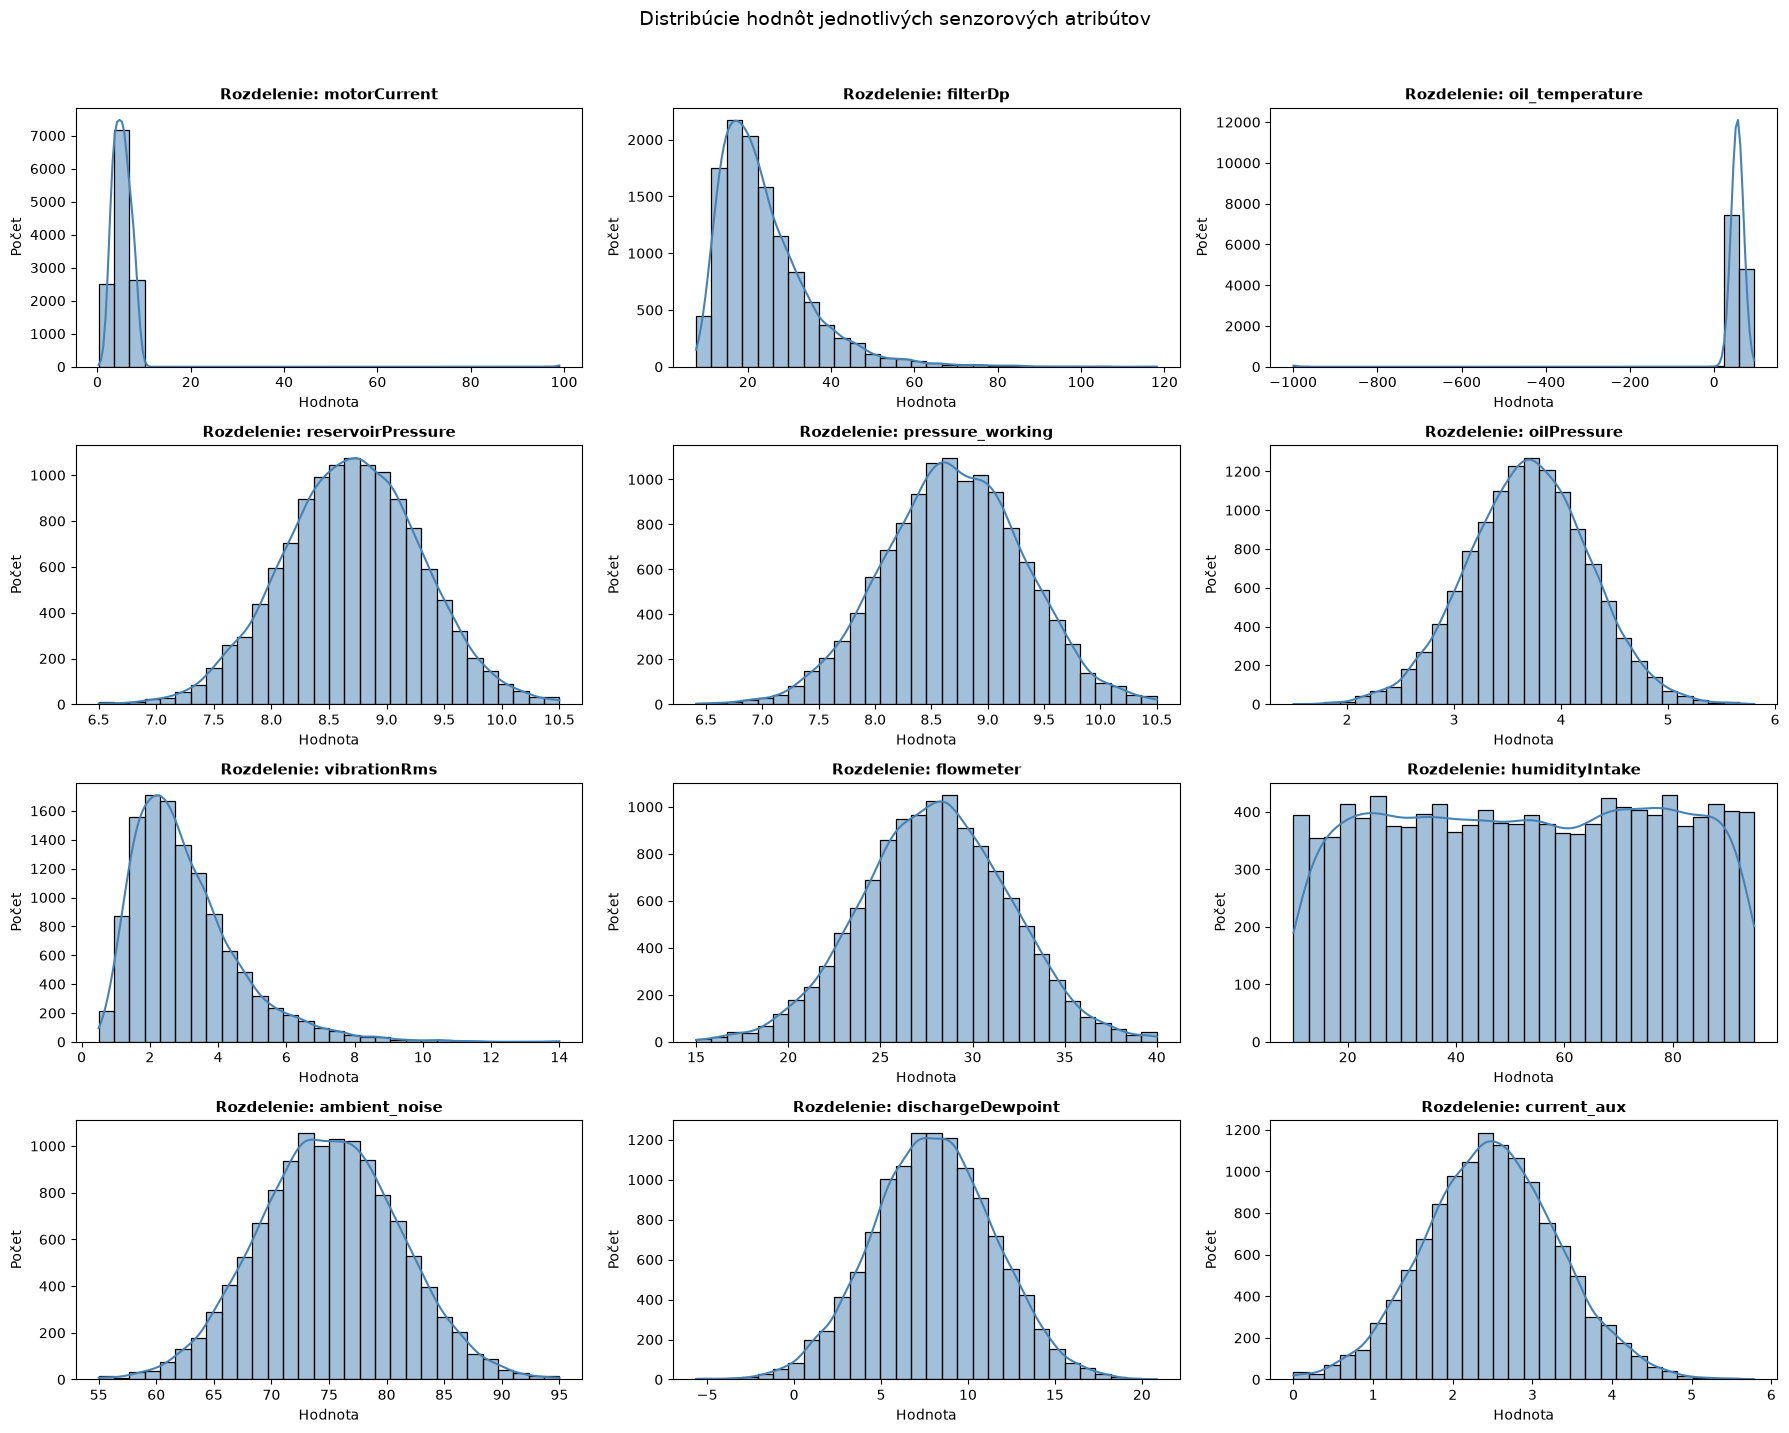

In [95]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(selected_sensor_cols):
    sns.histplot(readings[col].dropna(), kde=True, ax=axes[idx], color="steelblue", bins=30)
    axes[idx].set_title(f"Rozdelenie: {col}", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Hodnota")
    axes[idx].set_ylabel("Počet")

plt.suptitle("Distribúcie hodnôt jednotlivých senzorových atribútov", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

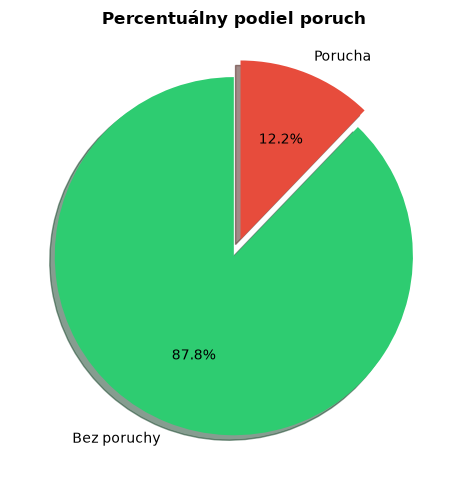

Cieľová premenná Failure: 10813 normálnych záznamov vs 1500 porúch.
Pomer porúch v datasete je 12.18% .


In [96]:
failure_counts = readings["Failure"].value_counts()
failure_percentages = readings["Failure"].value_counts(normalize=True) * 100

fig, axe = plt.subplots(1, 1, figsize=(13, 5))

axe.pie(failure_counts, labels=["Bez poruchy", "Porucha"], autopct="%1.1f%%",
           colors=["#2ecc71", "#e74c3c"], startangle=90, explode=[0, 0.1], shadow=True)
axe.set_title("Percentuálny podiel poruch", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Cieľová premenná Failure: {failure_counts[0]} normálnych záznamov vs {failure_counts[1]} porúch.")
print(f"Pomer porúch v datasete je {failure_percentages[1]:.2f}% .")

## 1.2 Čistenie datasetu

Vidíme že polia v datasete majú nekonzistentné názvy - `depot_id` vs `id_unit`, `versionFirmware` vs `model_hardware`. Aby sa s dátami lepšie pracovalo musíme ich premenovať aby používali jednu konvenciu. V Pythone sa štandardne používa `camel_case` preto aj my prejdeme na tento štýl.

In [97]:
units.rename(
    columns={
        "code_fleet": "fleet_code",
        "id_unit": "unit_id",
        "codeModel": "model_code",
    },
    inplace=True,
)
units.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   depot_id        2000 non-null   int64  
 1   fleet_code      2000 non-null   str    
 2   unit_id         2000 non-null   int64  
 3   duty_class      2000 non-null   str    
 4   service_hours   1900 non-null   float64
 5   install_region  2000 non-null   str    
 6   model_code      2000 non-null   str    
dtypes: float64(1), int64(2), str(4)
memory usage: 109.5 KB


In [98]:
readings.rename(
    columns={
        "id_unit": "unit_id",
        "cycleTs": "cycle_timestamp",
        "motorCurrent": "motor_current",
        "filterDp": "filter_dp",
        "reservoirPressure": "reservoir_pressure",
        "pressure_working": "working_pressure",
        "oilPressure": "oil_pressure",
        "vibrationRms": "vibration_rms",
        "flowmeter": "flow_meter",
        "humidityIntake": "humidity_intake",
        "dischargeDewpoint": "discharge_dewpoint",
        "current_aux": "aux_current",
        "Failure": "is_failing",
    },
    inplace=True,
)
readings.info()

<class 'pandas.DataFrame'>
RangeIndex: 12313 entries, 0 to 12312
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   unit_id             12313 non-null  str    
 1   cycle_timestamp     12313 non-null  str    
 2   motor_current       12313 non-null  float64
 3   filter_dp           11782 non-null  float64
 4   oil_temperature     12313 non-null  float64
 5   reservoir_pressure  12313 non-null  float64
 6   working_pressure    12313 non-null  float64
 7   oil_pressure        12313 non-null  float64
 8   vibration_rms       11799 non-null  float64
 9   flow_meter          12313 non-null  float64
 10  humidity_intake     11714 non-null  float64
 11  ambient_noise       12313 non-null  float64
 12  discharge_dewpoint  12313 non-null  float64
 13  aux_current         12313 non-null  float64
 14  is_failing          12313 non-null  int64  
dtypes: float64(12), int64(1), str(2)
memory usage: 1.4 MB


In [99]:
gateways.rename(
    columns={
        "gatewayId": "gateway_id",
        "installDate": "install_date",
        "id_unit": "unit_id",
        "Lon": "lon",
        "versionFirmware": "firmware_version",
        "model_hardware": "hardware_model",
    },
    inplace=True,
)
gateways.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gateway_id        16000 non-null  str    
 1   depot_id          16000 non-null  int64  
 2   install_date      16000 non-null  str    
 3   mac_address       16000 non-null  str    
 4   unit_id           2000 non-null   float64
 5   lon               16000 non-null  float64
 6   firmware_version  16000 non-null  str    
 7   hardware_model    16000 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 1000.1 KB


Mimo toho vidíme že v `gateways` je veľa záznamov v ktorých nemáme kompletné údaje - chýba `filter_dp`, `vibration_rms` alebo `humidity_intake`. Pre začiatok zistíme koľko ich je:

In [100]:
readings.isna().sum()

unit_id                 0
cycle_timestamp         0
motor_current           0
filter_dp             531
oil_temperature         0
reservoir_pressure      0
working_pressure        0
oil_pressure            0
vibration_rms         514
flow_meter              0
humidity_intake       599
ambient_noise           0
discharge_dewpoint      0
aux_current             0
is_failing              0
dtype: int64

In [101]:
readings.dropna().shape[0] / readings.shape[0] * 100

87.55786567042962

Po odstránení poškodených záznamov ich stále zostane viac ako 87%, preto sa to určite oplatí a môžeme pokračovať bez nich.

In [102]:
readings.dropna(inplace=True)

V tabuľke `gateways` je iný problém, máme 16 000 záznamov ale len 2 000 z nich má `unit_id` ktorý potrebujeme na prepojenie s `units` a `readings`. Podľa všetkého to je zoznam sieťového vybavenie (máme MAC adresy a názvy modelov ako `NODE-9`), z ktorého väčšina nesúvisí s dopravným systémom. Záznamy bez `unit_id` sú pre nás zbytočné a je lepšie ich odstrániť.

In [103]:
gateways.dropna(inplace=True)

In [104]:
gateways.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gateway_id        2000 non-null   str    
 1   depot_id          2000 non-null   int64  
 2   install_date      2000 non-null   str    
 3   mac_address       2000 non-null   str    
 4   unit_id           2000 non-null   float64
 5   lon               2000 non-null   float64
 6   firmware_version  2000 non-null   str    
 7   hardware_model    2000 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 125.1 KB


Posledná chyba je v tabuľke `units` kde pri 100 záznamoch z 2000 chýba hodnota `service_hours`. Tieto záznamy musíme odstrániť pretože údaj o služobnom veku vozidla je vždy dôležitý pri predpovedaní technických problémov alebo plánovaní kontroly.

In [105]:
units.dropna(inplace=True)

In [106]:
units.info()

<class 'pandas.DataFrame'>
Index: 1900 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   depot_id        1900 non-null   int64  
 1   fleet_code      1900 non-null   str    
 2   unit_id         1900 non-null   int64  
 3   duty_class      1900 non-null   str    
 4   service_hours   1900 non-null   float64
 5   install_region  1900 non-null   str    
 6   model_code      1900 non-null   str    
dtypes: float64(1), int64(2), str(4)
memory usage: 118.8 KB


### Normalizácia a dátové typy

Pri niektorých atribútoch vidíme že sú reprezentované nevhodným typom - `str` pre dátumy a kategorické premenné, `int64` pre boolean hodnotu `failure`. Napríklad v `units.duty_class` je jedna kategória zapísaná viac ako 3 spôsobmi:

In [107]:
units['duty_class'].unique()

<StringArray>
[       '1',        'L',        '2',    'heavy',      ' 3 ',      'med',
      ' 2 ',   'normal',        'H',    'light',      ' 1 ',  ' light ',
        'N',        '3', ' normal ',      ' H ',  ' heavy ',      ' N ',
      ' L ',    ' med ']
Length: 20, dtype: str

Problém vyriešime tak že ho prevedieme na `dtype=category` a normalizujeme hodnoty na jeden label pre každú kategóriu. Problém je že nevieme v akom poradí sú číselné kategórie - znamená 1 to isté čo "light" alebo "heavy"? Na to aby sme to zistili musíme porovnať ich rozdelenie.

<Axes: xlabel='duty_class', ylabel='Count'>

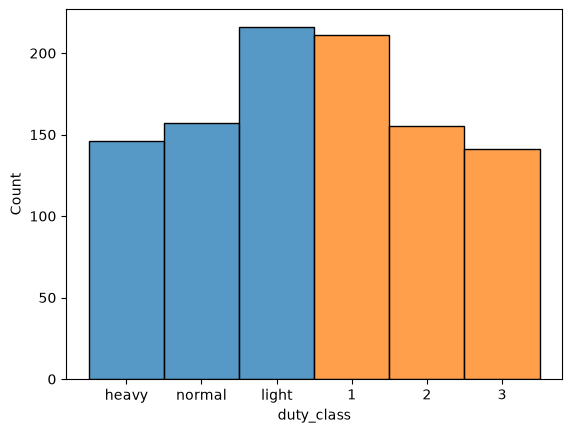

In [108]:
text_classes = ['light', 'normal', 'heavy']
num_classes = ['1', '2', '3']

sns.histplot(units.loc[units['duty_class'].isin(text_classes)]['duty_class'])
sns.histplot(units.loc[units['duty_class'].isin(num_classes)]['duty_class'])

Vidíme že v prvej časti grafu od "heavy" po "light" počet vozidiel stúpa, ale v druhej od 1 po 3 klesá - vznikol zrkadlový obraz. Z toho môžeme predpokladať že kategórie v grafe sú **naopak** - "1" v skutočnosti zodpovedá "light".

Teraz keď vieme čo ktorá hodnota znamená ich namapujeme na štandardné kategórie "light", "normal" a "heavy". Ešte pred tým ale odstránime whitespace na začiatku a konci záznamov.

In [109]:
mapping = {
    '1': 'light',
    '2': 'normal',
    '3': 'heavy',
    'L': 'light',
    'N': 'normal',
    'H': 'heavy',
    'med': 'normal',
}

def clean_duty_class(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    return mapping.get(value, value)

units["duty_class"] = units["duty_class"].map(clean_duty_class).astype('category')

units['duty_class'].unique()

['light', 'normal', 'heavy']
Categories (3, str): ['heavy', 'light', 'normal']

In [110]:
units.head(10)

,depot_id,fleet_code,unit_id,duty_class,service_hours,install_region,model_code
0,12,FB,1,light,8329.4,Fürstenfeldbruck,XC-7
1,110,FA,2,light,6371.8,Güstrow,APU-15
2,30,FD,3,light,16268.2,New Jasonfort,APU-20
3,52,FA,4,normal,9524.6,Heinsberg,APU-15
4,114,FB,5,heavy,28956.7,Güstrow,APU-15
5,116,FA,6,heavy,45000.0,Dachau,APU-20
6,73,FB,7,normal,6915.6,Großenhain,APU-20
7,55,FA,8,normal,9814.3,Jülich,APU-20
8,53,FC,9,heavy,4918.2,New Jasonfort,APU-12
9,67,FA,10,normal,9910.4,Wismar,APU-12
